# Credit Card Fraud Detection — Exploratory Data Analysis

This notebook explores the ULB credit card fraud dataset. The dataset is highly imbalanced — fraud transactions account for roughly **0.97%** of all records. Understanding the data distribution and feature behaviour is the essential first step before any modelling.

## 1. Imports & Load Data

We load the standard data-science stack and the raw dataset. All 50,492 rows and 31 columns are read into memory.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os

os.chdir(os.path.dirname(os.path.abspath("01_eda.ipynb")) if "__file__" not in dir() else os.path.dirname(__file__))
sys.path.append(".")
from utils import load_data

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
%matplotlib inline

df = load_data("data/creditcard.csv")
print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Dataset loaded: 50,492 rows × 31 columns


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,66706.0,1.199490,0.197301,0.616923,0.554820,-0.526523,-0.785182,-0.036202,-0.070460,-0.224568,...,-0.191542,-0.597586,0.148051,0.529668,0.158453,0.064369,-0.033132,0.011166,3.59,0
1,118737.0,2.054939,-0.005134,-1.050691,0.401563,-0.047484,-1.112092,0.218426,-0.350042,0.430742,...,-0.275390,-0.616070,0.338719,0.006520,-0.288834,0.198696,-0.062744,-0.059034,1.29,0
2,67555.0,-0.943726,-0.366261,2.292128,-1.909816,-0.305247,1.903637,-0.998268,0.757791,0.170689,...,0.109482,0.651761,-0.502554,-1.659885,0.669679,-0.000532,0.228359,0.088451,2.00,0
3,6428.0,-0.960946,0.864361,1.286077,0.131434,0.630708,-0.746227,0.567456,-0.281288,0.965197,...,-0.375636,-0.589018,0.275299,-0.161066,-0.491036,-0.020583,0.150700,0.179427,5.36,0
4,159884.0,1.688499,0.142083,-2.975027,0.857739,0.752403,-1.699499,0.883376,-0.527584,-0.050348,...,0.021742,-0.179006,-0.069067,0.967166,0.029453,0.613583,-0.095408,0.044466,195.00,0


## 2. Dataset Overview

We inspect shape, data types, descriptive statistics, duplicate rows, and missing values. `V1`–`V28` are anonymised PCA components provided by the dataset authors; `Time` is seconds since the first transaction, `Amount` is the transaction amount in Euros, and `Class` is the binary target (0 = legitimate, 1 = fraud).

In [2]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nDescriptive statistics:")
df.describe().round(3)

Shape: (50492, 31)

Data types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Descriptive statistics:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,50492.000,50492.000,50492.000,50492.000,50492.000,50492.000,50492.000,50492.000,50492.000,50492.000,...,50492.000,50492.000,50492.000,50492.000,50492.000,50492.000,50492.000,50492.000,50492.000,50492.000
mean,94841.311,-0.036,0.025,-0.057,0.044,-0.013,-0.012,-0.052,0.009,-0.011,...,0.002,-0.000,0.000,-0.001,-0.003,0.002,0.003,0.001,87.205,0.010
std,47493.217,2.085,1.721,1.739,1.487,1.452,1.334,1.433,1.329,1.144,...,0.797,0.734,0.643,0.607,0.523,0.484,0.414,0.306,227.164,0.098
min,0.000,-46.855,-48.061,-31.104,-5.520,-28.816,-20.870,-43.557,-50.420,-13.434,...,-22.889,-8.887,-30.270,-2.837,-6.429,-1.727,-9.544,-8.308,0.000,0.000
25%,54334.750,-0.929,-0.597,-0.922,-0.826,-0.699,-0.775,-0.568,-0.205,-0.648,...,-0.228,-0.551,-0.162,-0.356,-0.319,-0.328,-0.070,-0.052,5.660,0.000
50%,84737.500,0.015,0.076,0.167,-0.003,-0.056,-0.279,0.036,0.025,-0.050,...,-0.026,0.007,-0.010,0.041,0.015,-0.047,0.002,0.012,21.990,0.000
75%,139325.750,1.312,0.819,1.016,0.770,0.622,0.394,0.570,0.331,0.598,...,0.188,0.526,0.149,0.438,0.346,0.245,0.095,0.080,76.805,0.000
max,172787.000,2.420,22.058,4.102,13.129,29.162,21.190,26.250,20.007,10.371,...,27.203,8.362,17.752,4.016,5.852,3.517,9.880,15.870,8360.000,1.000


In [3]:
print(f"Duplicate rows : {df.duplicated().sum()}")
print(f"Missing values : {df.isnull().sum().sum()}")
print("\nClass counts:")
print(df["Class"].value_counts())
print(f"\nFraud rate    : {df['Class'].mean()*100:.2f}%")

Duplicate rows : 53
Missing values : 0

Class counts:
Class
0    50000
1      492
Name: count, dtype: int64

Fraud rate    : 0.97%


## 3. Class Distribution

The class imbalance is severe — only ~0.97% of transactions are fraudulent. A naive classifier that always predicts 'legitimate' would achieve 99%+ accuracy, making accuracy a nearly useless metric. We will rely on **Precision, Recall, F1, and PR-AUC** instead.

/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_57032/4067723406.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Class", data=df, palette=["steelblue", "tomato"], ax=axes[0])
/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_57032/4067723406.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Legitimate", "Fraud"])


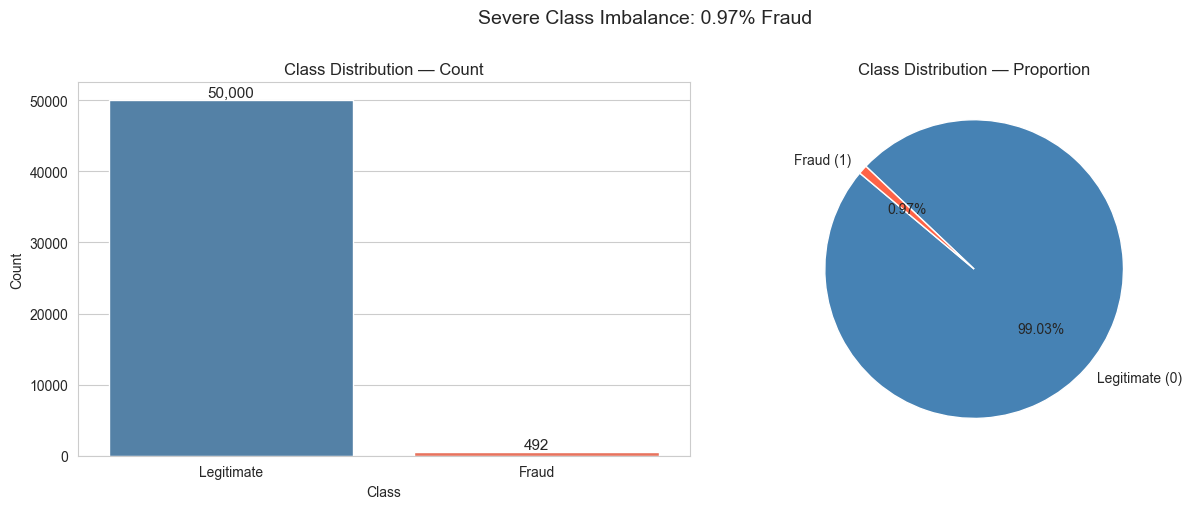

In [4]:
class_counts = df["Class"].value_counts()
labels = ["Legitimate (0)", "Fraud (1)"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Countplot
sns.countplot(x="Class", data=df, palette=["steelblue", "tomato"], ax=axes[0])
axes[0].set_title("Class Distribution — Count")
axes[0].set_xticklabels(["Legitimate", "Fraud"])
axes[0].set_xlabel("Class"); axes[0].set_ylabel("Count")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width()/2, p.get_height()),
                     ha="center", va="bottom", fontsize=11)

# Pie chart
axes[1].pie(class_counts, labels=labels, autopct="%1.2f%%",
            colors=["steelblue", "tomato"], startangle=140)
axes[1].set_title("Class Distribution — Proportion")

plt.suptitle("Severe Class Imbalance: 0.97% Fraud", fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

## 4. Transaction Amount Distribution

Fraudulent transactions tend to have a very different amount distribution compared to legitimate ones. Many fraud transactions cluster at small amounts, possibly to avoid detection thresholds, while legitimate transactions span a much wider range.

/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_57032/3592165857.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([legit["Amount"], fraud["Amount"]], labels=["Legitimate", "Fraud"],


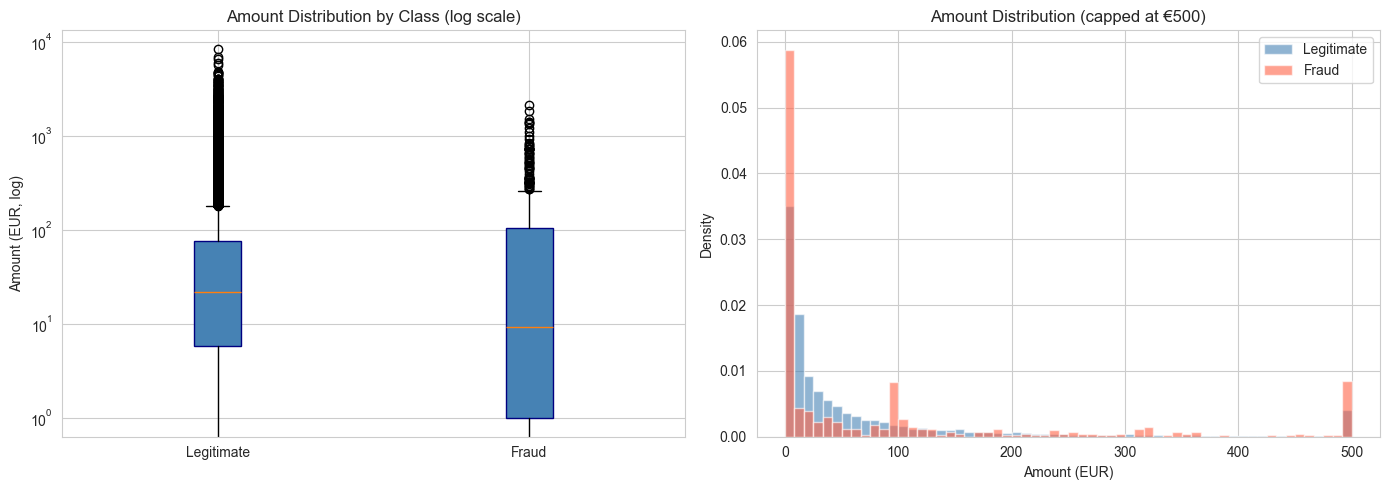

Legitimate — median: €22.00, mean: €86.86, max: €8360.00
Fraud       — median: €9.25, mean: €122.21, max: €2125.87


In [5]:
fraud = df[df["Class"] == 1]
legit = df[df["Class"] == 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot — log scale to handle outliers
axes[0].boxplot([legit["Amount"], fraud["Amount"]], labels=["Legitimate", "Fraud"],
                patch_artist=True, boxprops=dict(facecolor="steelblue", color="navy"))
axes[0].set_yscale("log")
axes[0].set_title("Amount Distribution by Class (log scale)")
axes[0].set_ylabel("Amount (EUR, log)")

# Overlaid histogram (capped at 500 for readability)
cap = 500
axes[1].hist(legit["Amount"].clip(upper=cap), bins=60, alpha=0.6, color="steelblue",
             density=True, label="Legitimate")
axes[1].hist(fraud["Amount"].clip(upper=cap), bins=60, alpha=0.6, color="tomato",
             density=True, label="Fraud")
axes[1].set_title(f"Amount Distribution (capped at €{cap})")
axes[1].set_xlabel("Amount (EUR)"); axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout(); plt.show()

print(f"Legitimate — median: €{legit['Amount'].median():.2f}, mean: €{legit['Amount'].mean():.2f}, max: €{legit['Amount'].max():.2f}")
print(f"Fraud       — median: €{fraud['Amount'].median():.2f}, mean: €{fraud['Amount'].mean():.2f}, max: €{fraud['Amount'].max():.2f}")

## 5. Time Distribution by Class

`Time` records the number of seconds elapsed since the first transaction in the dataset (covering ~48 hours). We check whether fraudulent transactions concentrate at particular times of day, which could indicate overnight or off-peak fraud patterns.

/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_57032/3208249594.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Class", y="Time_hours", data=time_df,


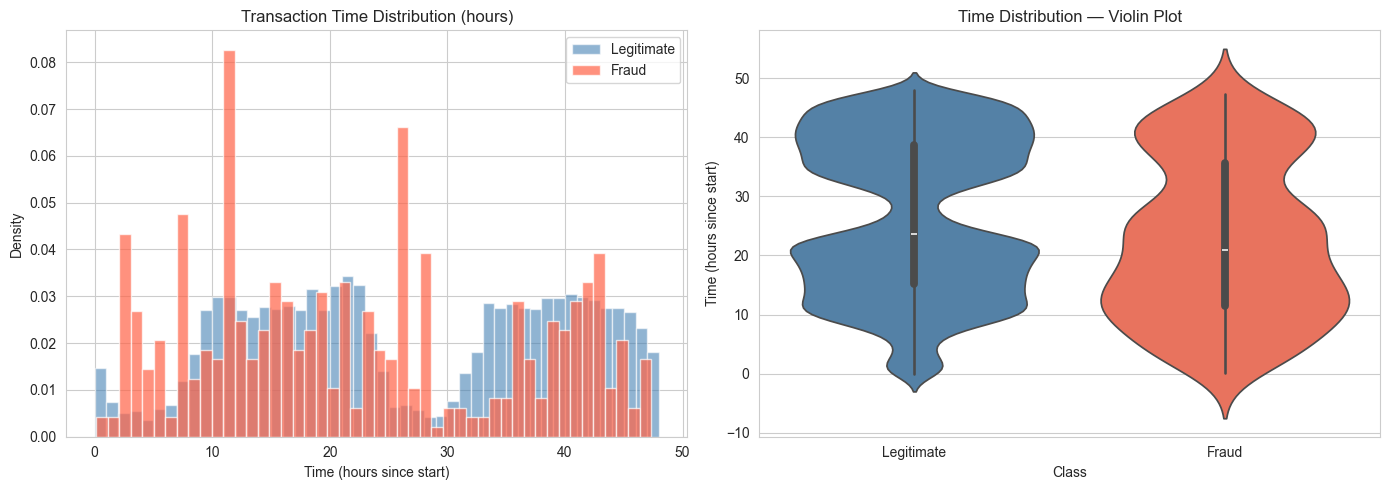

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(legit["Time"] / 3600, bins=48, alpha=0.6, color="steelblue",
             density=True, label="Legitimate")
axes[0].hist(fraud["Time"] / 3600, bins=48, alpha=0.7, color="tomato",
             density=True, label="Fraud")
axes[0].set_title("Transaction Time Distribution (hours)")
axes[0].set_xlabel("Time (hours since start)"); axes[0].set_ylabel("Density")
axes[0].legend()

# Violin plot
time_df = pd.DataFrame({"Time_hours": df["Time"] / 3600,
                         "Class": df["Class"].map({0: "Legitimate", 1: "Fraud"})})
sns.violinplot(x="Class", y="Time_hours", data=time_df,
               palette={"Legitimate": "steelblue", "Fraud": "tomato"}, ax=axes[1])
axes[1].set_title("Time Distribution — Violin Plot")
axes[1].set_ylabel("Time (hours since start)")

plt.tight_layout(); plt.show()

## 6. V-Feature Distributions: Fraud vs Legitimate

The V-features are the result of PCA transformation applied by the dataset authors to protect cardholder identity. Even so, several components show clearly separated distributions between classes, indicating strong discriminative power. We visualise the eight most correlated V-features.

Top 8 V-features by |correlation with Class|:
V14    0.5707
V17    0.5450
V12    0.5101
V10    0.4399
V16    0.4048
V3     0.3980
V7     0.3818
V11    0.3411
Name: Class, dtype: float64


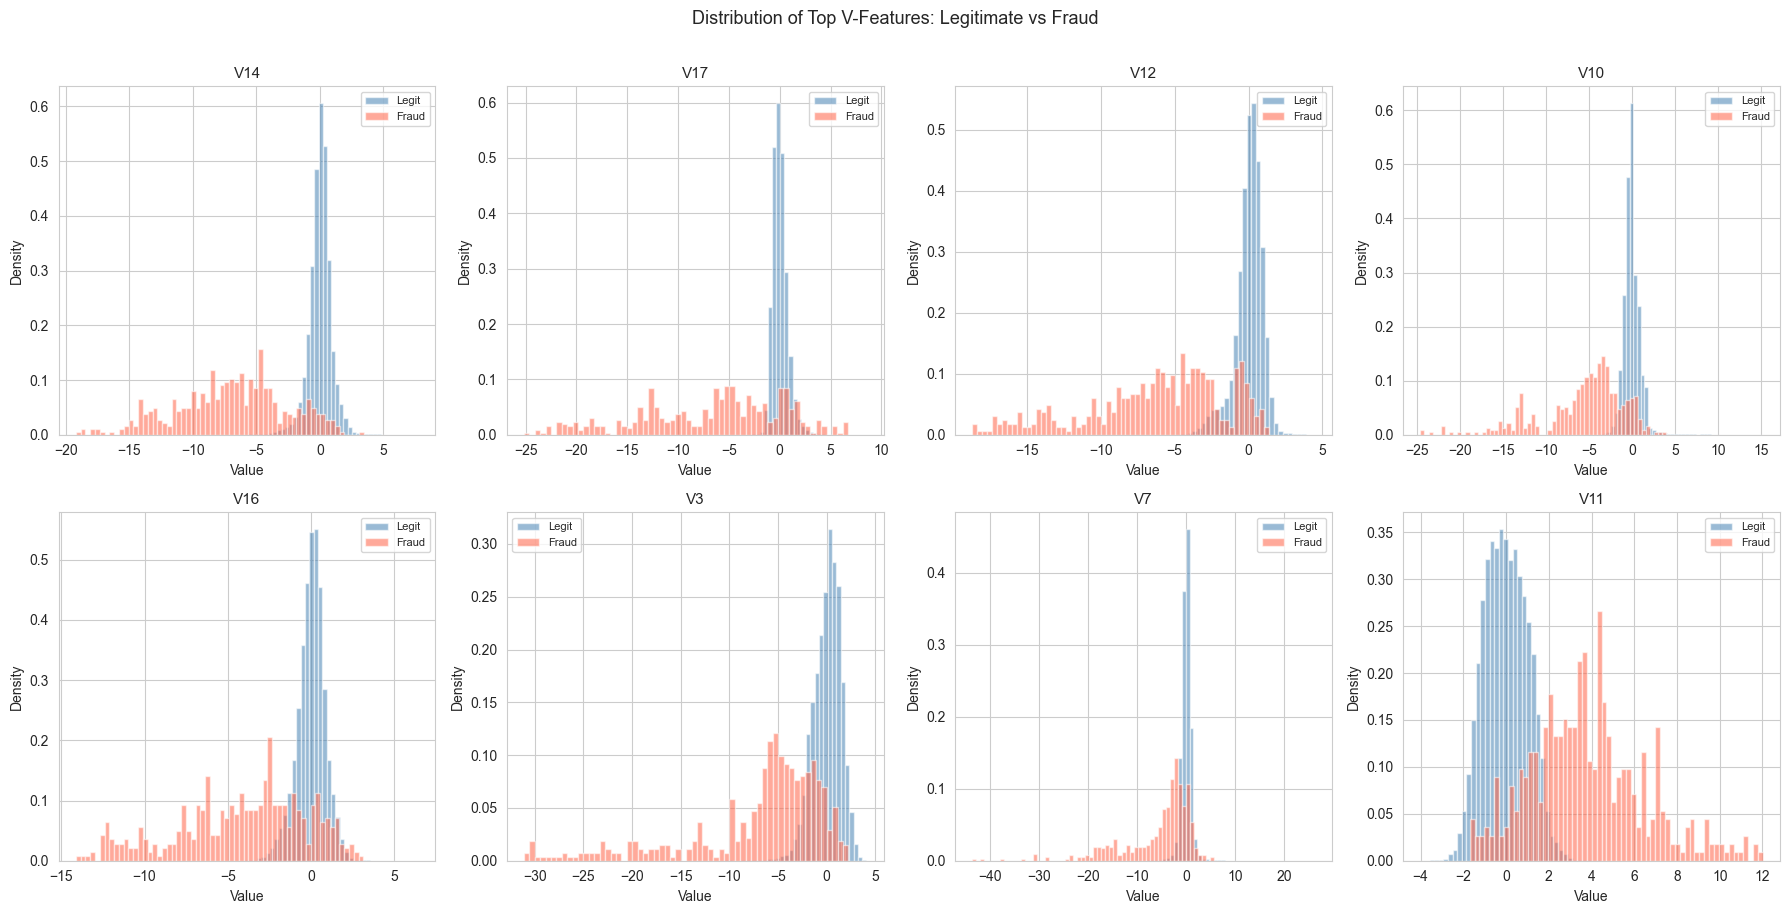

In [7]:
# Compute absolute correlation with Class for each V-feature
v_cols = [f"V{i}" for i in range(1, 29)]
corrs = df[v_cols + ["Class"]].corr()["Class"].drop("Class").abs().sort_values(ascending=False)
top8 = corrs.head(8).index.tolist()
print("Top 8 V-features by |correlation with Class|:")
print(corrs.head(8).round(4))

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, col in zip(axes.flatten(), top8):
    ax.hist(legit[col], bins=60, alpha=0.55, color="steelblue", density=True, label="Legit")
    ax.hist(fraud[col], bins=60, alpha=0.55, color="tomato",    density=True, label="Fraud")
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("Value"); ax.set_ylabel("Density")
    ax.legend(fontsize=8)
plt.suptitle("Distribution of Top V-Features: Legitimate vs Fraud", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

## 7. Correlation Analysis

We compute the full correlation matrix and separately visualise each feature's correlation with `Class`. Features with high absolute correlation are the most informative for fraud detection.

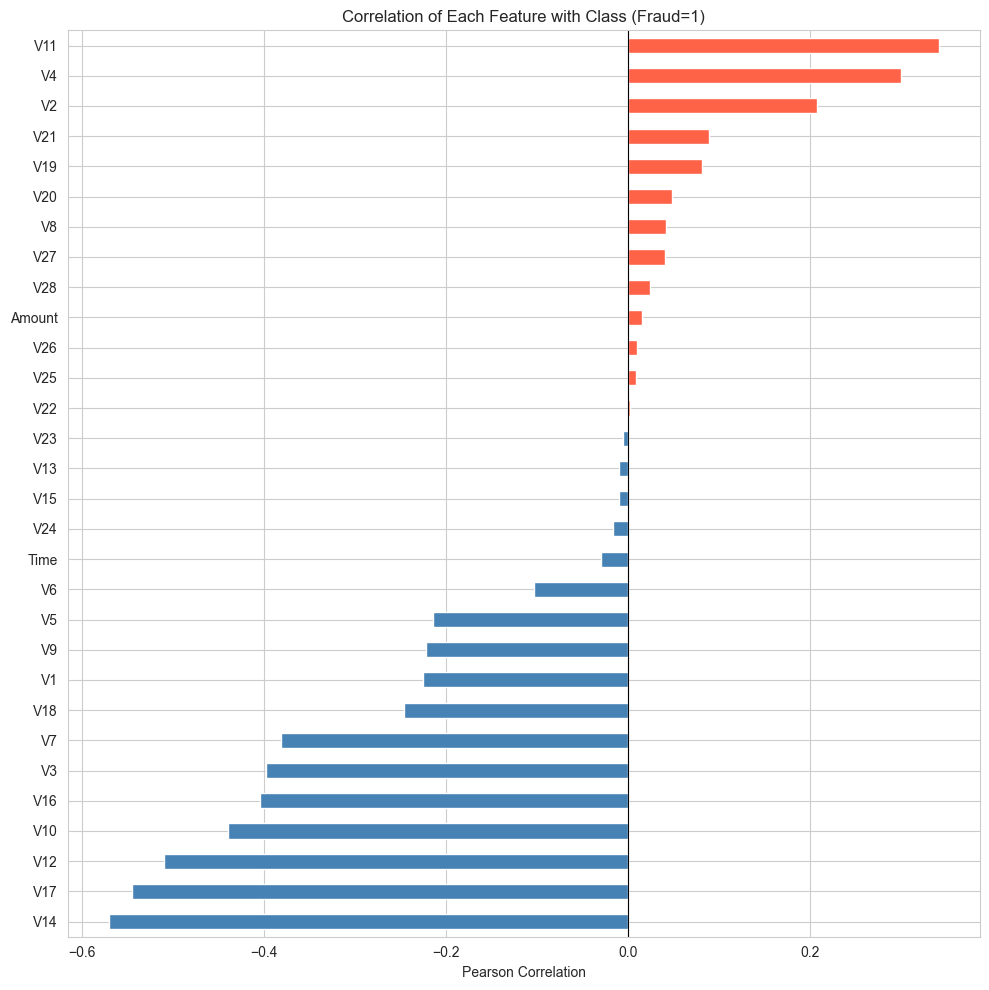

In [8]:
# Correlation with target
target_corr = df.corr()["Class"].drop("Class").sort_values()

plt.figure(figsize=(10, 10))
target_corr.plot(kind="barh", color=["tomato" if c > 0 else "steelblue" for c in target_corr])
plt.title("Correlation of Each Feature with Class (Fraud=1)")
plt.xlabel("Pearson Correlation"); plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout(); plt.show()

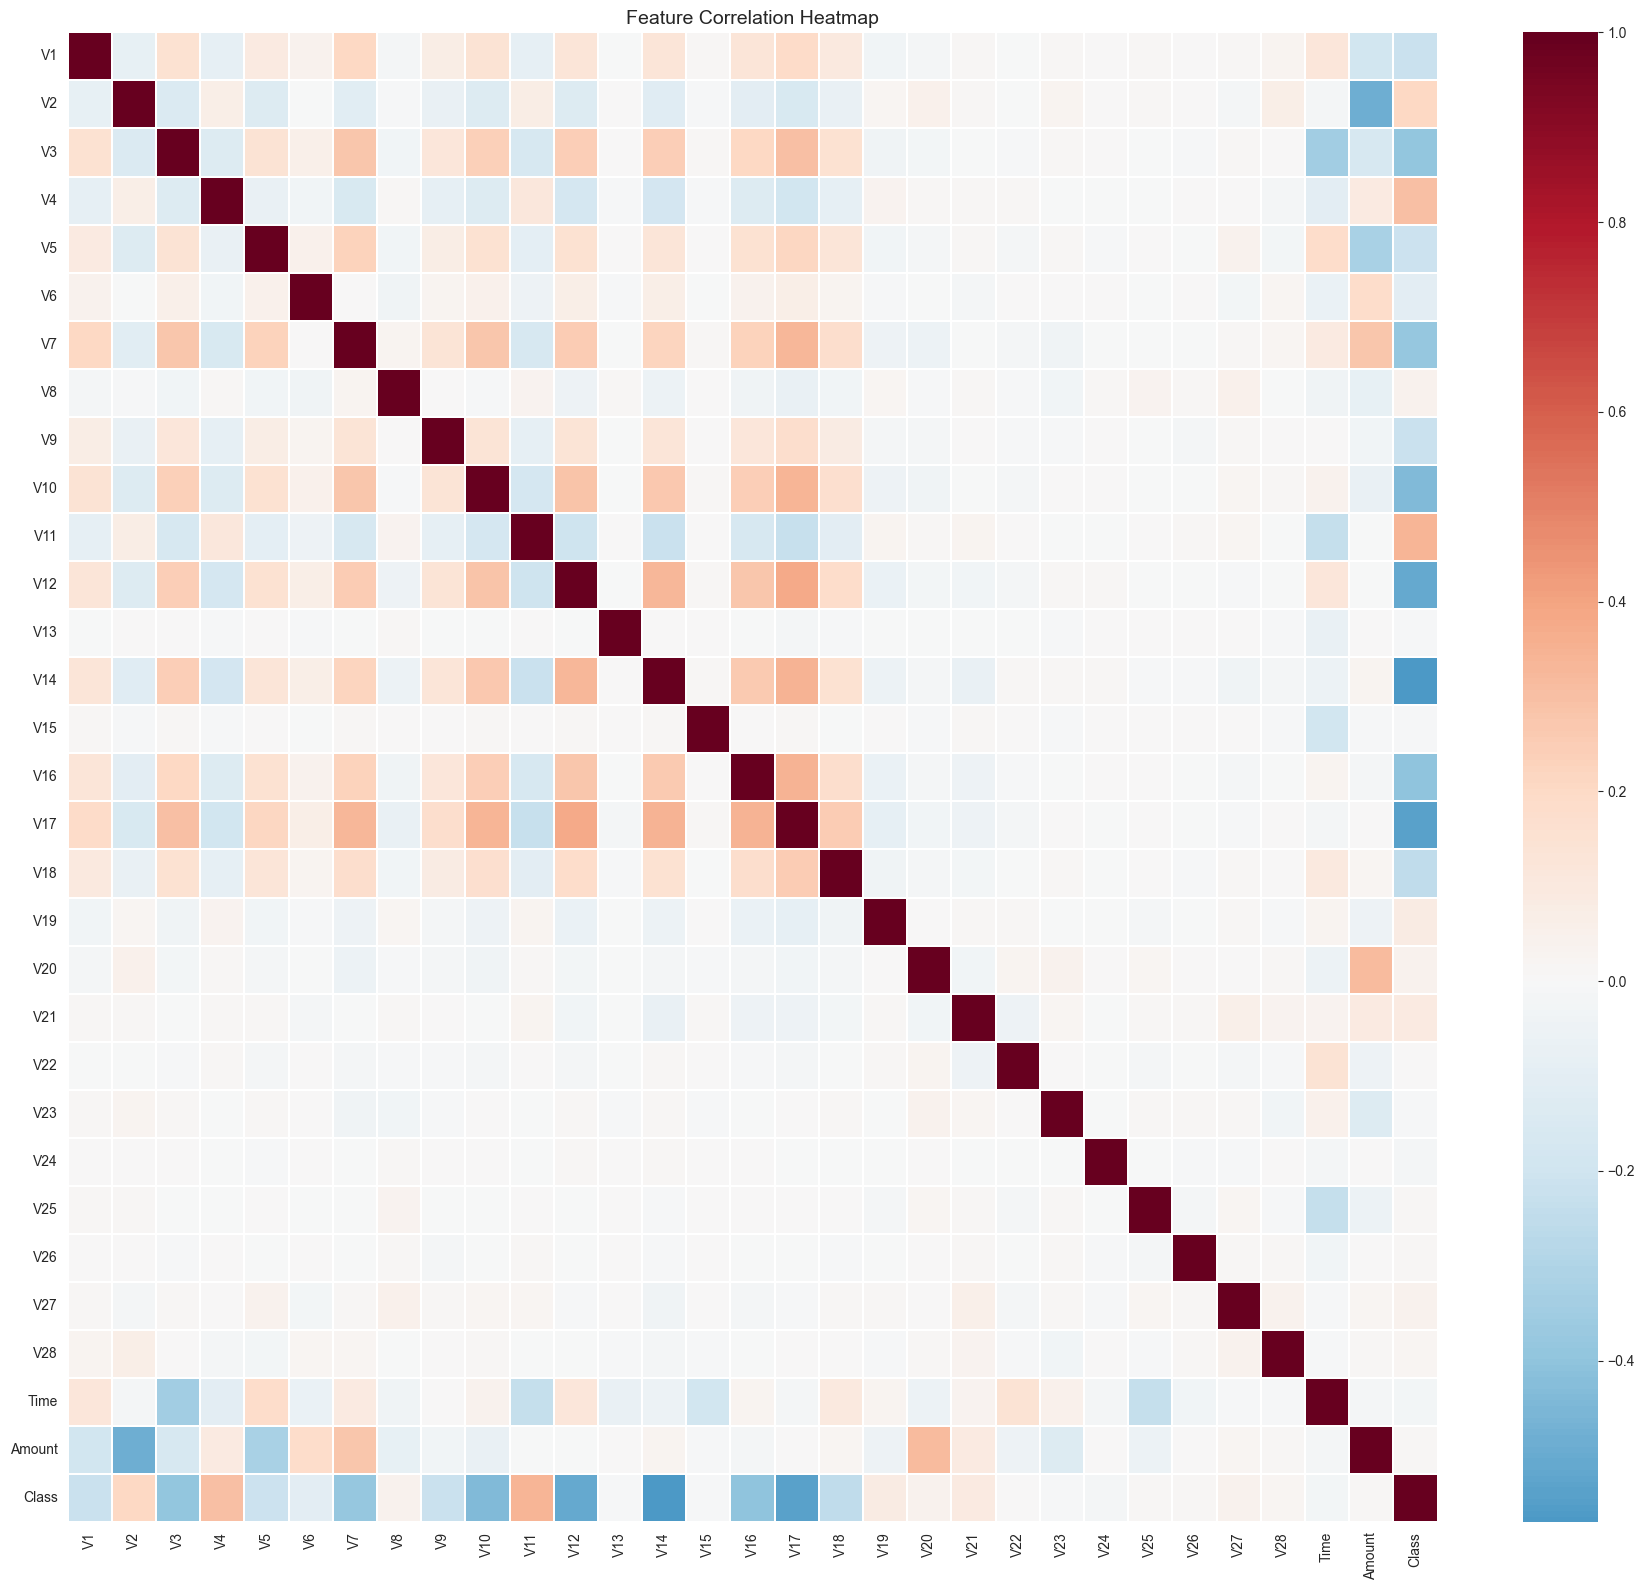

In [9]:
# Full heatmap — use only V-features + Amount + Time + Class
fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(df[v_cols + ["Time", "Amount", "Class"]].corr(),
            cmap="RdBu_r", center=0, annot=False, linewidths=0.3, ax=ax)
ax.set_title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout(); plt.show()

## 8. Summary of Key Findings

Below is a structured summary of the most important observations from the EDA.

In [10]:
summary = pd.DataFrame({
    "Finding": [
        "Severe class imbalance",
        "No missing values",
        "53 duplicate rows",
        "Amount skew",
        "Fraud amounts smaller on median",
        "Time: two daily cycles visible",
        "V4, V11, V14, V17 most correlated with fraud",
        "V-features already PCA-scaled",
    ],
    "Detail": [
        "0.97% fraud (492 / 50,492) — accuracy is not a useful metric",
        "All 31 columns are complete",
        "Will be dropped in notebook 02",
        "Highly right-skewed — RobustScaler will be applied",
        "Fraud median €9.25 vs legitimate median €21.95",
        "Fraud slightly over-represented in early hours",
        "Absolute Pearson correlation > 0.30 with Class",
        "V1–V28 left untouched during preprocessing",
    ]
})
summary

,Finding,Detail
0,Severe class imbalance,"0.97% fraud (492 / 50,492) — accuracy is not a..."
1,No missing values,All 31 columns are complete
2,53 duplicate rows,Will be dropped in notebook 02
3,Amount skew,Highly right-skewed — RobustScaler will be app...
4,Fraud amounts smaller on median,Fraud median €9.25 vs legitimate median €21.95
5,Time: two daily cycles visible,Fraud slightly over-represented in early hours
6,"V4, V11, V14, V17 most correlated with fraud",Absolute Pearson correlation > 0.30 with Class
7,V-features already PCA-scaled,V1–V28 left untouched during preprocessing
